# 1. Notebook header & imports

In [1]:
# 03_xai_explainability.ipynb
# Explainable AI for Type 2 Diabetes Risk (PIMA + NHANES)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import shap

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)

shap.initjs()

# 2. Load data, models, and scalers

In [2]:
# ---- Load cleaned datasets ----
pima = pd.read_csv("../data/pima_clean.csv")
nhanes = pd.read_csv("../data/nhanes_clean.csv")

print("PIMA:", pima.shape)
print("NHANES:", nhanes.shape)

# ---- Load models ----
pima_xgb = joblib.load("../models/pima_xgb.pkl")            # original best model
nhanes_xgb = joblib.load("../models/nhanes_xgb_tuned.pkl")  # tuned best model

# ---- Load scalers (from your preprocessing / training) ----
pima_scaler = joblib.load("../models/pima_scaler.pkl")
nhanes_scaler = joblib.load("../models/nhanes_scaler.pkl")

PIMA: (768, 9)
NHANES: (10761, 12)


# 3. Prepare X / y and scaled feature matrices

In [3]:
# ---------- PIMA ----------
X_pima = pima.drop("Outcome", axis=1)
y_pima = pima["Outcome"]

X_pima_scaled = pima_scaler.transform(X_pima)
X_pima_scaled_df = pd.DataFrame(X_pima_scaled, columns=X_pima.columns)

# ---------- NHANES ----------
X_nhanes = nhanes.drop("diabetes_label", axis=1)
y_nhanes = nhanes["diabetes_label"]

X_nhanes_scaled = nhanes_scaler.transform(X_nhanes)
X_nhanes_scaled_df = pd.DataFrame(X_nhanes_scaled, columns=X_nhanes.columns)

# 4. Build SHAP explainers

In [4]:
# For speed, we can use a sample of rows for global plots
pima_sample = X_pima_scaled_df.sample(n=min(500, len(X_pima_scaled_df)), random_state=42)
nhanes_sample = X_nhanes_scaled_df.sample(n=min(1000, len(X_nhanes_scaled_df)), random_state=42)

# ---------- Create SHAP explainers ----------
explainer_pima = shap.TreeExplainer(pima_xgb)
explainer_nhanes = shap.TreeExplainer(nhanes_xgb)

# Compute SHAP values
shap_values_pima = explainer_pima.shap_values(pima_sample)
shap_values_nhanes = explainer_nhanes.shap_values(nhanes_sample)

len(shap_values_pima), len(shap_values_nhanes)

(500, 1000)

# 5. GLOBAL EXPLANATIONS

## 5.1 PIMA – global importance

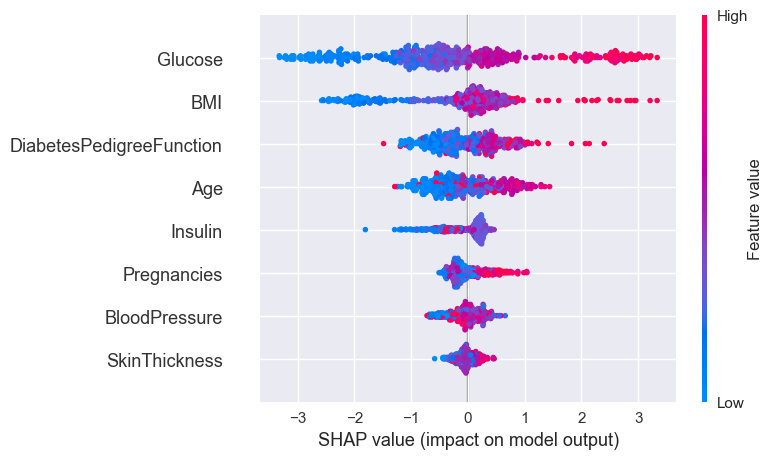

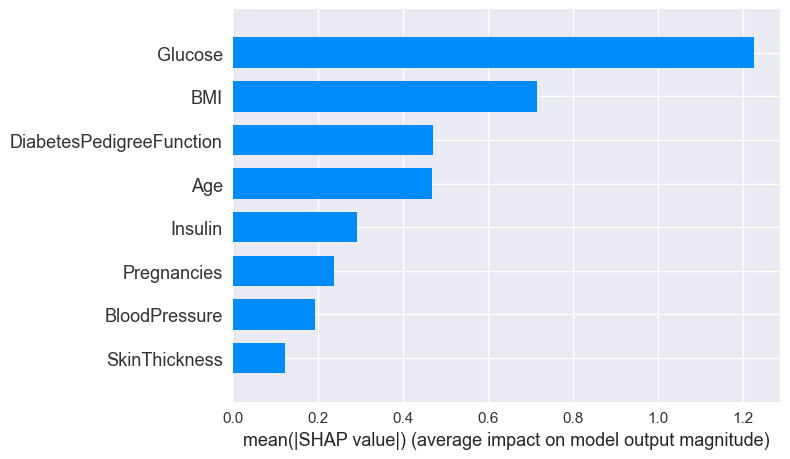

In [5]:
# ===== PIMA – Global SHAP Summary (beeswarm) =====
shap.summary_plot(
    shap_values_pima,
    pima_sample,
    show=True,
    plot_type="dot"
)

# ===== PIMA – Global Feature Importance (bar) =====
shap.summary_plot(
    shap_values_pima,
    pima_sample,
    show=True,
    plot_type="bar"
)

## 5.2 NHANES – global importance

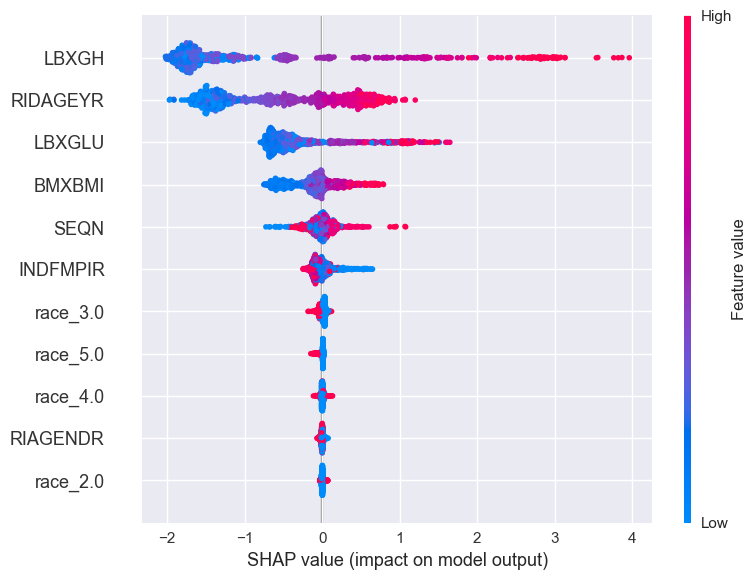

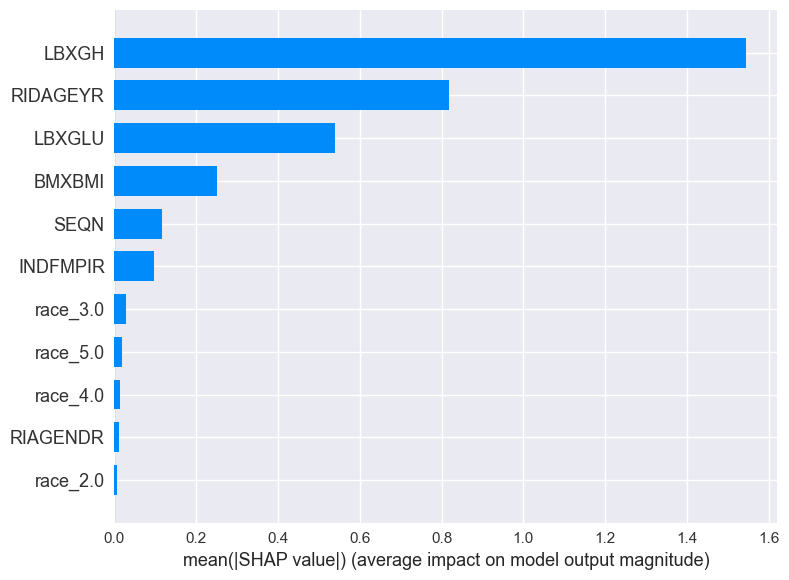

In [13]:
# ===== NHANES – Global SHAP Summary (beeswarm) =====
shap.summary_plot(
    shap_values_nhanes,
    nhanes_sample,
    show=False,
    plot_type="dot"
)

plt.savefig(
    "../figures/xai/shap_summary_nhanes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ===== NHANES – Global Feature Importance (bar) =====
shap.summary_plot(
    shap_values_nhanes,
    nhanes_sample,
    show=False,
    plot_type="bar"
)

plt.savefig(
    "../figures/xai/shap_bar_nhanes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 6. LOCAL EXPLANATIONS (individual prediction)

In [7]:
def explain_individual_case(model, explainer, X_df, original_df, idx, dataset_name="NHANES"):
    """
    model: trained XGB model
    explainer: SHAP TreeExplainer
    X_df: scaled features (DataFrame)
    original_df: original (unscaled) features (DataFrame) for displaying values
    idx: row index to explain (int)
    """
    row_scaled = X_df.iloc[[idx]]          # scaled features (used by model)
    row_original = original_df.iloc[[idx]] # original values (for printing)

    # prediction
    proba = model.predict_proba(row_scaled.values)[:, 1][0]
    pred = int(proba >= 0.5)

    print(f"=== {dataset_name} – Individual Explanation (index {idx}) ===")
    print("Predicted diabetes risk probability:", f"{proba:.3f}")
    print("Predicted class:", pred)
    print("\nOriginal feature values:")
    display(row_original)

    # SHAP values for this instance
    shap_values_row = explainer.shap_values(row_scaled)

    # Force plot
    shap.force_plot(
        explainer.expected_value,
        shap_values_row,
        row_scaled,
        matplotlib=True
    )

    # Waterfall plot (requires shap.Explanation in newer versions)
    try:
        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value,
            shap_values_row[0],
            feature_names=row_scaled.columns
        )
    except Exception as e:
        print("Waterfall plot not available in this SHAP version:", e)

## 6.1 Example: explain one NHANES person

=== NHANES – Individual Explanation (index 10) ===
Predicted diabetes risk probability: 0.001
Predicted class: 0

Original feature values:


,SEQN,RIAGENDR,RIDAGEYR,INDFMPIR,BMXBMI,LBXGH,LBXGLU,race_2.0,race_3.0,race_4.0,race_5.0
10,62190.0,1.0,15.0,0.54,17.0,5.2,93.0,False,False,False,False


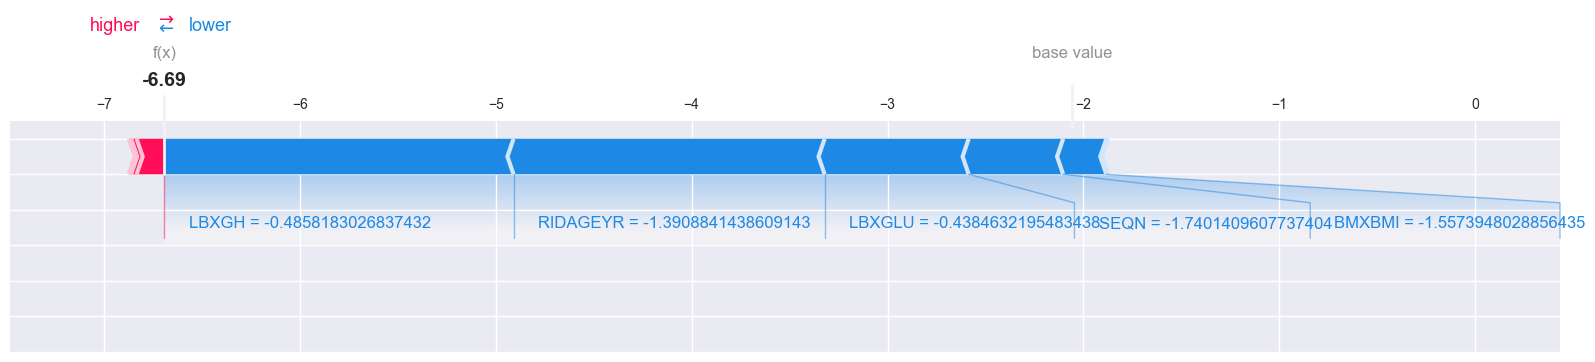

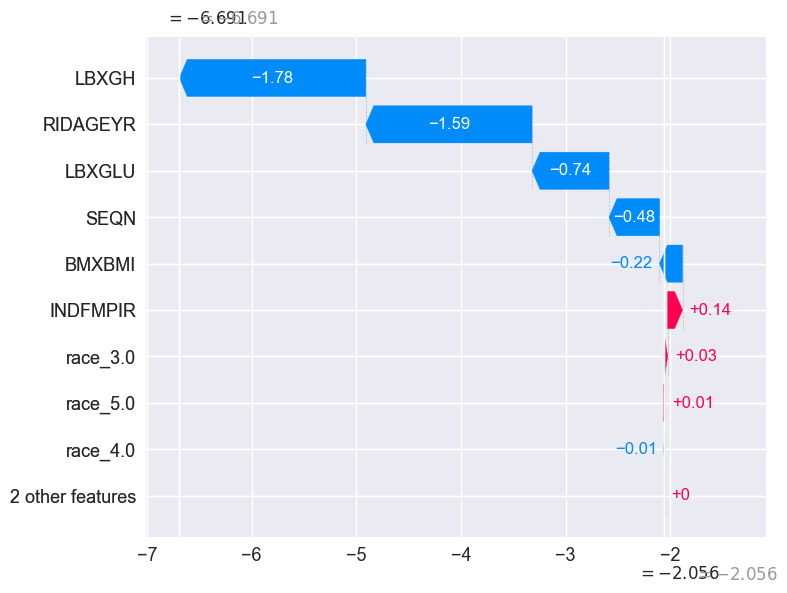

In [8]:
explain_individual_case(
    model=nhanes_xgb,
    explainer=explainer_nhanes,
    X_df=X_nhanes_scaled_df,
    original_df=X_nhanes,   # unscaled
    idx=10,
    dataset_name="NHANES"
)

## 6.2 Example: explain one PIMA person

=== PIMA – Individual Explanation (index 5) ===
Predicted diabetes risk probability: 0.033
Predicted class: 0

Original feature values:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30


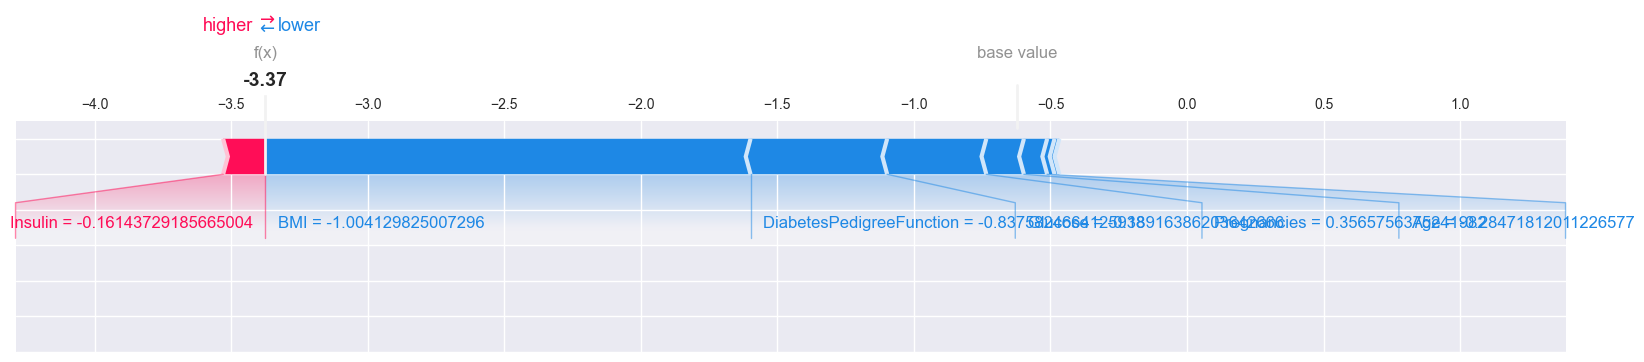

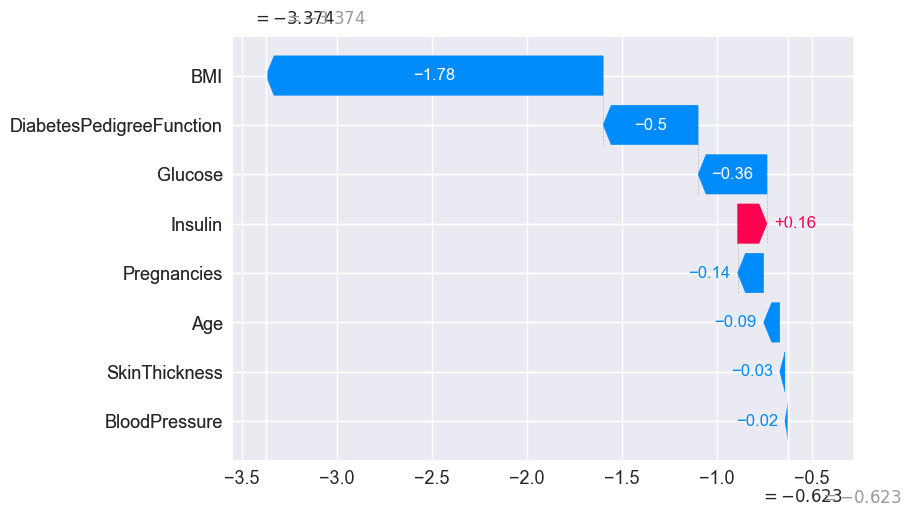

In [9]:
explain_individual_case(
    model=pima_xgb,
    explainer=explainer_pima,
    X_df=X_pima_scaled_df,
    original_df=X_pima,
    idx=5,
    dataset_name="PIMA"
)

# 7. SIMPLE “WHAT-IF” / COUNTERFACTUAL STYLE ANALYSIS

### Example for NHANES:

In [10]:
def what_if_change_feature(model, X_scaled_df, original_df, idx, feature, new_value):
    """
    Show how prediction changes if we manually change one feature.
    """
    print(f"=== WHAT-IF: change {feature} for index {idx} ===")

    # current prediction
    row_scaled = X_scaled_df.iloc[[idx]].copy()
    row_original = original_df.iloc[[idx]].copy()

    proba_before = model.predict_proba(row_scaled.values)[:, 1][0]

    print("Before change:")
    print(f"{feature} = {row_original[feature].values[0]}")
    print(f"Predicted risk = {proba_before:.3f}")

    # apply change in ORIGINAL data, then rescale that row only
    row_original_changed = row_original.copy()
    row_original_changed[feature] = new_value

    # we need to scale using the same scaler
    if "BMXBMI" in original_df.columns:   # crude way to know if this is NHANES
        scaler = nhanes_scaler
    else:
        scaler = pima_scaler

    row_scaled_changed = scaler.transform(row_original_changed.values)
    proba_after = model.predict_proba(row_scaled_changed)[:, 1][0]

    print("\nAfter change:")
    print(f"{feature} = {new_value}")
    print(f"Predicted risk = {proba_after:.3f}")
    print(f"Δ Risk = {proba_after - proba_before:+.3f}")

## Example: lower BMI for one NHANES subject

In [11]:
what_if_change_feature(
    model=nhanes_xgb,
    X_scaled_df=X_nhanes_scaled_df,
    original_df=X_nhanes,
    idx=10,
    feature="BMXBMI",
    new_value=25.0   # simulate weight loss
)

=== WHAT-IF: change BMXBMI for index 10 ===
Before change:
BMXBMI = 17.0
Predicted risk = 0.001

After change:
BMXBMI = 25.0
Predicted risk = 0.001
Δ Risk = -0.000


C:\Users\windows 11\.conda\envs\diabetes-ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# 8. Save SHAP values

In [12]:
# Save mean |SHAP| values as feature importance tables
pima_importance = pd.DataFrame({
    "feature": pima_sample.columns,
    "mean_abs_shap": np.mean(np.abs(shap_values_pima), axis=0)
}).sort_values("mean_abs_shap", ascending=False)

nhanes_importance = pd.DataFrame({
    "feature": nhanes_sample.columns,
    "mean_abs_shap": np.mean(np.abs(shap_values_nhanes), axis=0)
}).sort_values("mean_abs_shap", ascending=False)

pima_importance.to_csv("../models/pima_shap_importance.csv", index=False)
nhanes_importance.to_csv("../models/nhanes_shap_importance.csv", index=False)

pima_importance.head(), nhanes_importance.head()

(                    feature  mean_abs_shap
 1                   Glucose       1.226238
 5                       BMI       0.715822
 6  DiabetesPedigreeFunction       0.472457
 7                       Age       0.469205
 4                   Insulin       0.291614,
     feature  mean_abs_shap
 5     LBXGH       1.544019
 2  RIDAGEYR       0.819077
 6    LBXGLU       0.539295
 4    BMXBMI       0.251755
 0      SEQN       0.115283)